In [60]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error


In [28]:
df = pd.read_csv("Plant_1_Merged.csv")


In [29]:
df["DATE_TIME"] = pd.to_datetime(df["DATE_TIME"])

In [30]:
df["Hour"] = df["DATE_TIME"].dt.hour
df["Day"] = df["DATE_TIME"].dt.day
df["Month"] = df["DATE_TIME"].dt.month
df["Weekday"] = df["DATE_TIME"].dt.day_name()

In [31]:
print(df.head())

   DATE_TIME  PLANT_ID     SOURCE_KEY_x  DC_POWER  AC_POWER  DAILY_YIELD  \
0 2020-05-15   4135001  1BY6WEcLGh8j5v7       0.0       0.0          0.0   
1 2020-05-15   4135001  1IF53ai7Xc0U56Y       0.0       0.0          0.0   
2 2020-05-15   4135001  3PZuoBAID5Wc2HD       0.0       0.0          0.0   
3 2020-05-15   4135001  7JYdWkrLSPkdwr4       0.0       0.0          0.0   
4 2020-05-15   4135001  McdE0feGgRqW7Ca       0.0       0.0          0.0   

   TOTAL_YIELD     SOURCE_KEY_y  AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  \
0    6259559.0  HmiyD2TTLFNqkNe            25.184316           22.857507   
1    6183645.0  HmiyD2TTLFNqkNe            25.184316           22.857507   
2    6987759.0  HmiyD2TTLFNqkNe            25.184316           22.857507   
3    7602960.0  HmiyD2TTLFNqkNe            25.184316           22.857507   
4    7158964.0  HmiyD2TTLFNqkNe            25.184316           22.857507   

   IRRADIATION  Hour  Day  Month Weekday  
0          0.0     0   15      5  Friday  


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   DATE_TIME            68778 non-null  datetime64[ns]
 1   PLANT_ID             68778 non-null  int64         
 2   SOURCE_KEY_x         68778 non-null  object        
 3   DC_POWER             68778 non-null  float64       
 4   AC_POWER             68778 non-null  float64       
 5   DAILY_YIELD          68778 non-null  float64       
 6   TOTAL_YIELD          68778 non-null  float64       
 7   SOURCE_KEY_y         68774 non-null  object        
 8   AMBIENT_TEMPERATURE  68774 non-null  float64       
 9   MODULE_TEMPERATURE   68774 non-null  float64       
 10  IRRADIATION          68774 non-null  float64       
 11  Hour                 68778 non-null  int32         
 12  Day                  68778 non-null  int32         
 13  Month                68778 non-

In [33]:
df.isnull().sum()
df.describe()
df.sample(5)
df.dtypes
print("Duplicate Rows:", df.duplicated().sum())
print(df.columns.tolist())

Duplicate Rows: 0
['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY_x', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD', 'SOURCE_KEY_y', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'Hour', 'Day', 'Month', 'Weekday']


In [34]:
print("Start:", df["DATE_TIME"].min())
print("End:", df["DATE_TIME"].max())

Start: 2020-05-15 00:00:00
End: 2020-06-17 23:45:00


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

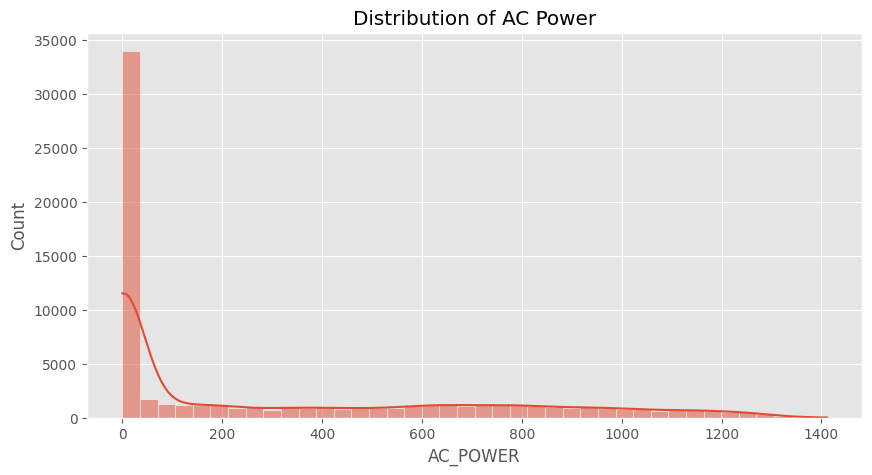

In [36]:
plt.figure(figsize=(10,5))

sns.histplot(df["AC_POWER"], bins=40, kde=True)

plt.title("Distribution of AC Power")
plt.show()

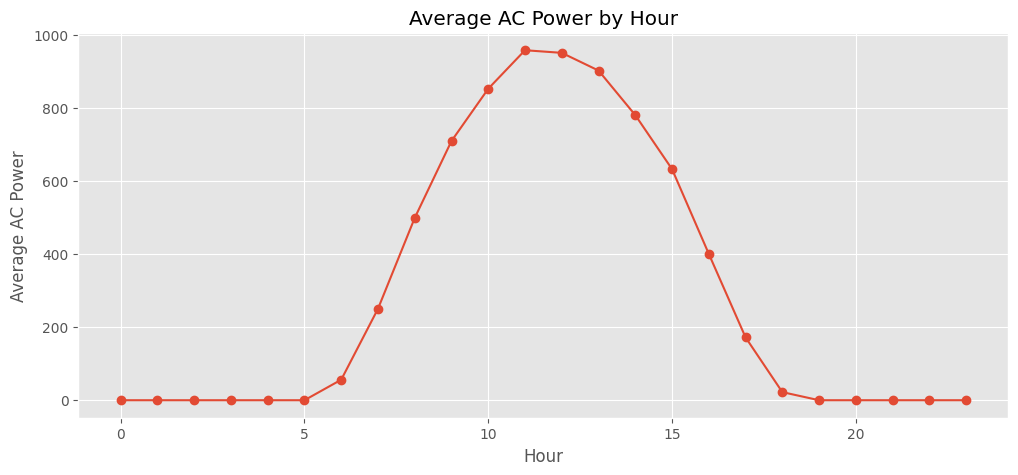

In [46]:
hourly = df.groupby("Hour")["AC_POWER"].mean()

plt.figure(figsize=(12,5))
hourly.plot(marker="o")

plt.title("Average AC Power by Hour")
plt.xlabel("Hour")
plt.ylabel("Average AC Power")
plt.grid(True)

plt.show()

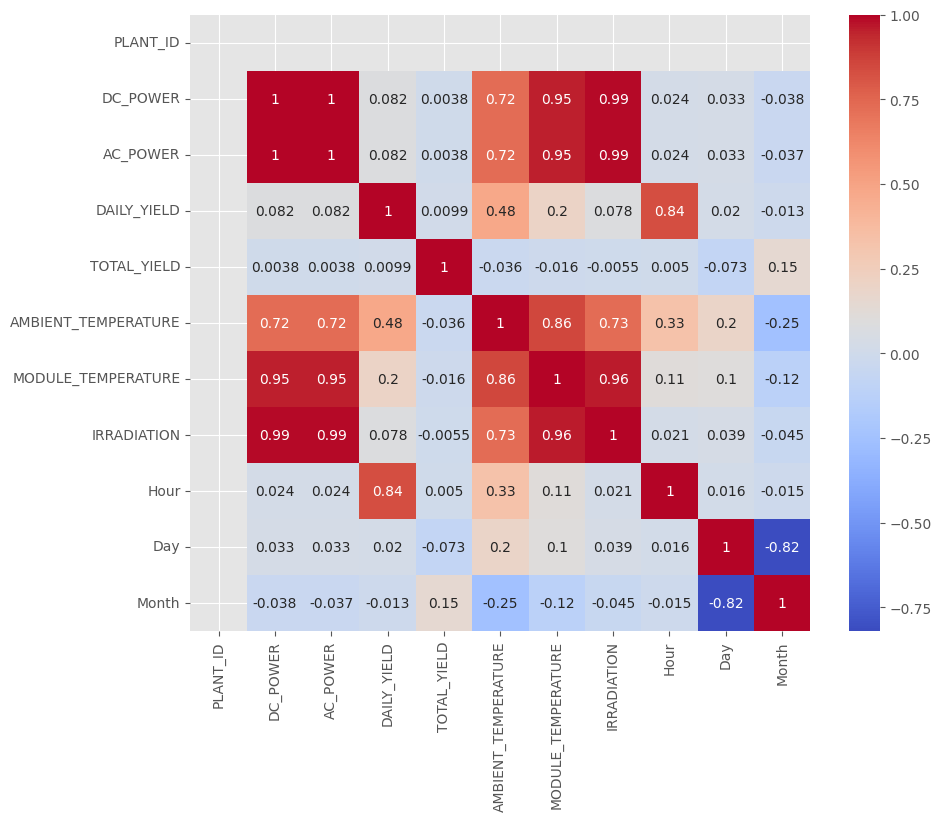

In [37]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [38]:
print(df.columns.tolist())
print(df.dtypes)

['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY_x', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD', 'SOURCE_KEY_y', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'Hour', 'Day', 'Month', 'Weekday']
DATE_TIME              datetime64[ns]
PLANT_ID                        int64
SOURCE_KEY_x                   object
DC_POWER                      float64
AC_POWER                      float64
DAILY_YIELD                   float64
TOTAL_YIELD                   float64
SOURCE_KEY_y                   object
AMBIENT_TEMPERATURE           float64
MODULE_TEMPERATURE            float64
IRRADIATION                   float64
Hour                            int32
Day                             int32
Month                           int32
Weekday                        object
dtype: object


In [39]:
print("AC_POWER" in df.columns)
print("IRRADIATION" in df.columns)

True
True


In [40]:
print(df.columns.tolist())

['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY_x', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD', 'SOURCE_KEY_y', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'Hour', 'Day', 'Month', 'Weekday']


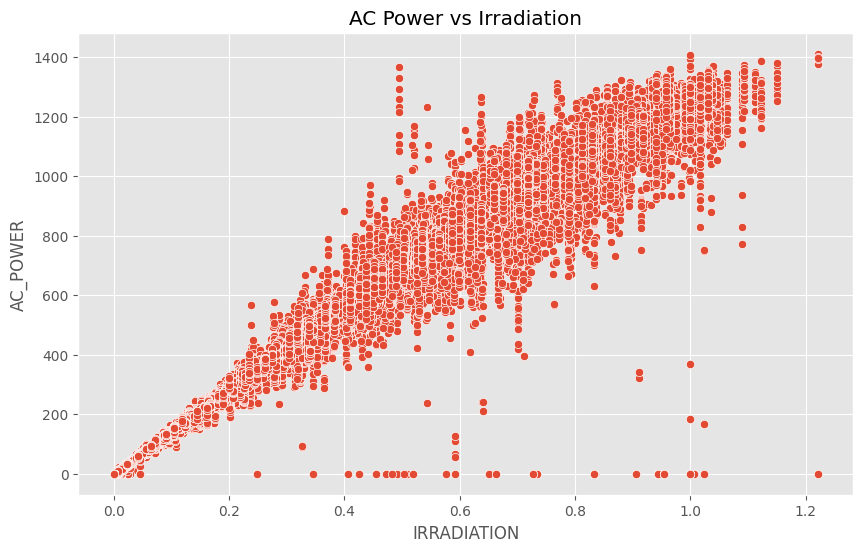

In [41]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="IRRADIATION",
    y="AC_POWER"
)

plt.title("AC Power vs Irradiation")

plt.show()

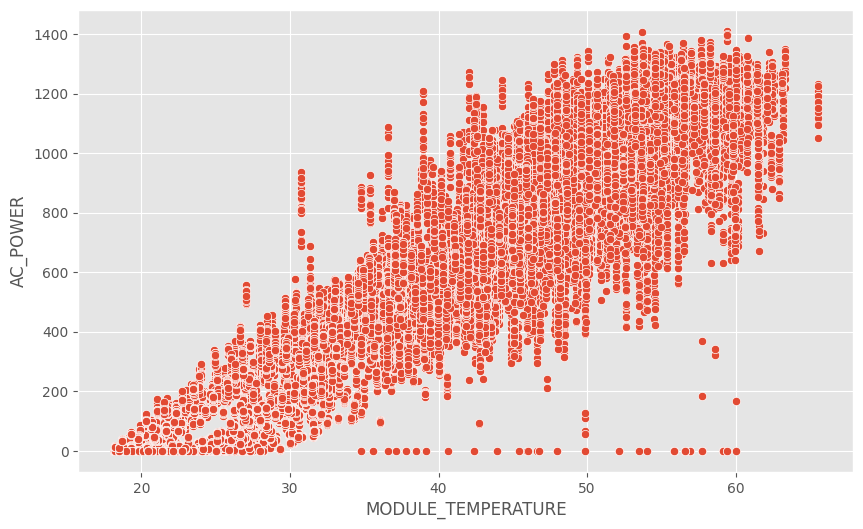

In [42]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="MODULE_TEMPERATURE",
    y="AC_POWER"
)

plt.show()

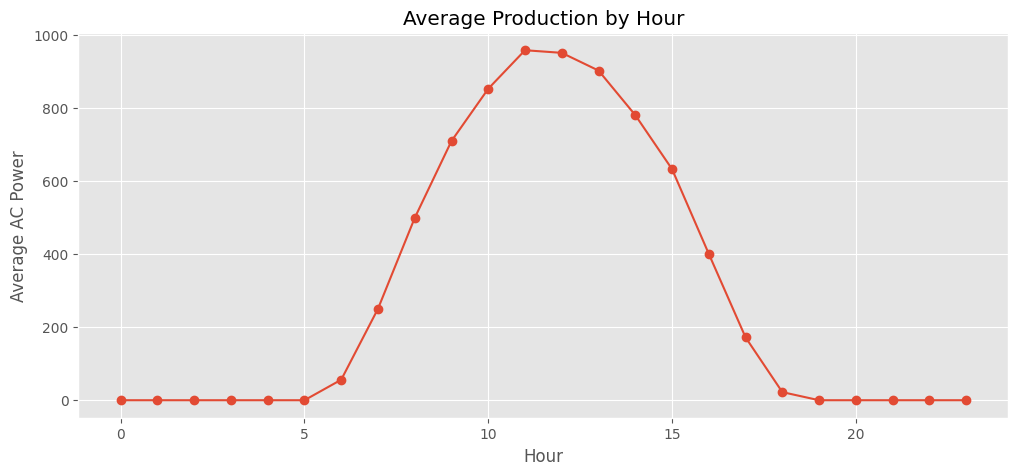

In [43]:
df["Hour"] = df["DATE_TIME"].dt.hour

plt.figure(figsize=(12,5))

df.groupby("Hour")["AC_POWER"].mean().plot(marker="o")

plt.ylabel("Average AC Power")
plt.title("Average Production by Hour")

plt.show()

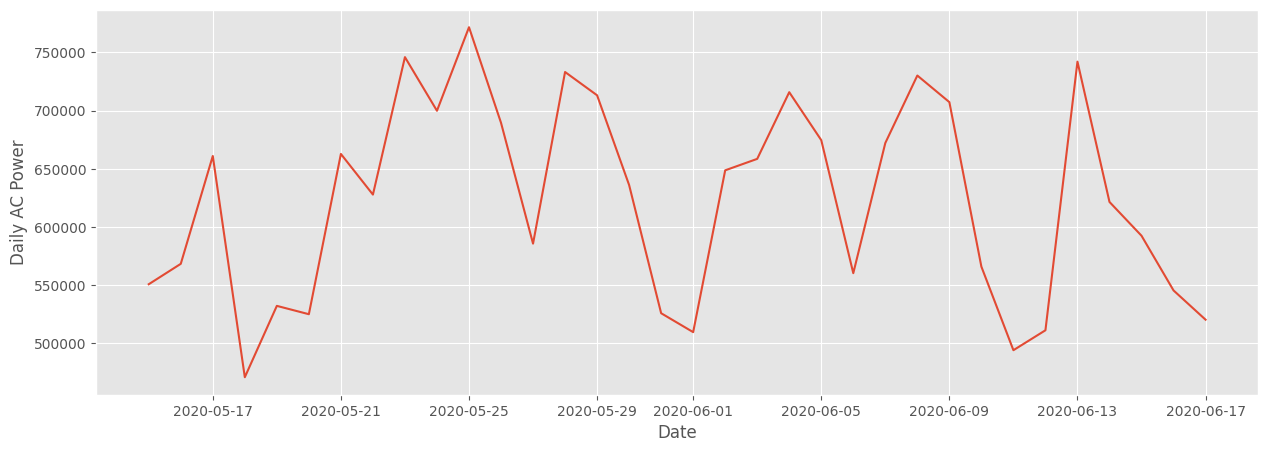

In [44]:
df["Date"] = df["DATE_TIME"].dt.date

plt.figure(figsize=(15,5))

df.groupby("Date")["AC_POWER"].sum().plot()

plt.ylabel("Daily AC Power")

plt.show()

In [45]:
best = df.groupby("SOURCE_KEY_x")["AC_POWER"].mean().sort_values(ascending=False)

print(best)

SOURCE_KEY_x
adLQvlD726eNBSB    319.693862
1IF53ai7Xc0U56Y    315.488026
3PZuoBAID5Wc2HD    314.967354
McdE0feGgRqW7Ca    314.046321
VHMLBKoKgIrUVDU    313.900096
iCRJl6heRkivqQ3    312.540320
uHbuxQJl8lW7ozc    312.467844
ZnxXDlPa8U1GXgE    312.346427
zVJPv84UY57bAof    311.676665
YxYtjZvoooNbGkE    310.930334
wCURE6d3bPkepu2    310.064044
pkci93gMrogZuBj    309.670213
rGa61gmuvPhdLxV    309.345658
WRmjgnKYAwPKWDb    308.575465
zBIq5rxdHJRwDNY    307.925344
sjndEbLyjtCKgGv    307.912265
ZoEaEvLYb1n2sOq    306.980623
z9Y9gH1T5YWrNuG    306.492026
7JYdWkrLSPkdwr4    306.385671
ih0vzX44oOqAx2f    302.962438
1BY6WEcLGh8j5v7    281.124073
bvBOhCH3iADSZry    276.778938
Name: AC_POWER, dtype: float64


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


In [50]:
df = pd.read_csv("backdata.csv")

# Convert DATE_TIME to datetime
df["DATE_TIME"] = pd.to_datetime(df["DATE_TIME"], dayfirst=True)

# =====================================================
# Filter Only One Inverter
# =====================================================

df = df[df["SOURCE_KEY_x"] == "1BY6WEcLGh8j5v7"]

# Sort by time
df = df.sort_values("DATE_TIME").reset_index(drop=True)

print("Total Samples:", len(df))

Total Samples: 3154


In [51]:
# =====================================================
# Drop Unnecessary Columns
# =====================================================

df.drop(
    columns=[
        "SOURCE_KEY_x",
        "SOURCE_KEY_y",
        "PLANT_ID"
    ],
    inplace=True
)

In [76]:
# ==========================================
# Create Future Target (Forecast Next Timestamp)
# ==========================================

df["Target"] = df["AC_POWER"].shift(-1)

# Remove last row (Target becomes NaN)
df = df.dropna()

# ==========================================
# Feature Selection
# ==========================================

features = [
    "IRRADIATION",
    "DAILY_YIELD"
]

target = "Target"

X = df[features]
y = df[target]

In [78]:
print(features)
print(X.columns)

['IRRADIATION', 'DAILY_YIELD']
Index(['IRRADIATION', 'DAILY_YIELD'], dtype='object')



BACKTEST FOLD 21
Training Samples : 527
Testing Samples  : 525
MAE  : 68.373
RMSE : 134.159
R²   : 0.8961
MAPE : 1329625891438984960.00%

First 10 Predictions
   Actual  Predicted
0     0.0        0.0
1     0.0        0.0
2     0.0        0.0
3     0.0        0.0
4     0.0        0.0
5     0.0        0.0
6     0.0        0.0
7     0.0        0.0
8     0.0        0.0
9     0.0        0.0


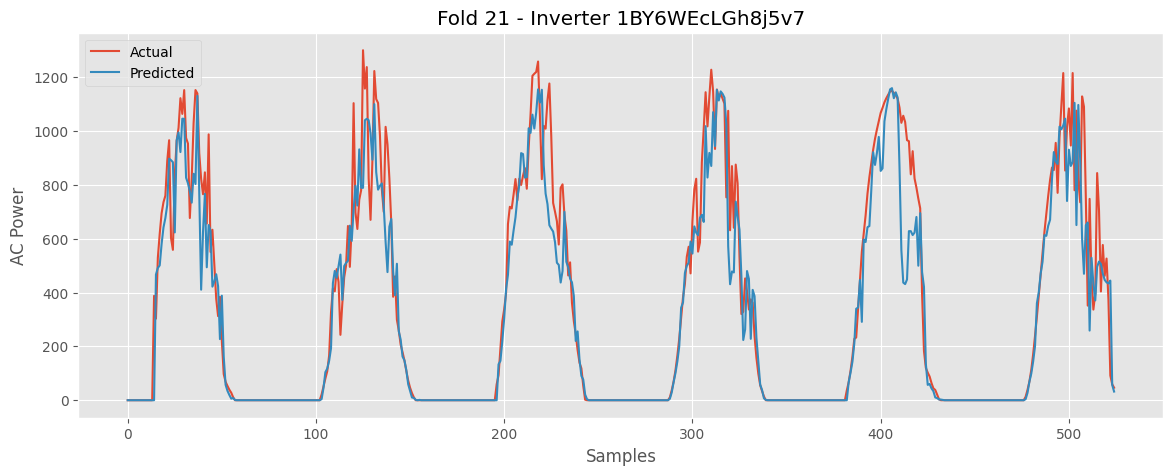


BACKTEST FOLD 22
Training Samples : 1052
Testing Samples  : 525
MAE  : 60.515
RMSE : 120.592
R²   : 0.8978
MAPE : 1329625891438984960.00%

First 10 Predictions
      Actual  Predicted
0  32.871429  28.987768
1   0.000000  11.946196
2   0.000000  38.756625
3   0.000000  10.161929
4   0.000000   0.382634
5   0.000000   0.382634
6   0.000000   0.382634
7   0.000000   0.382634
8   0.000000   0.382634
9   0.000000   0.382634


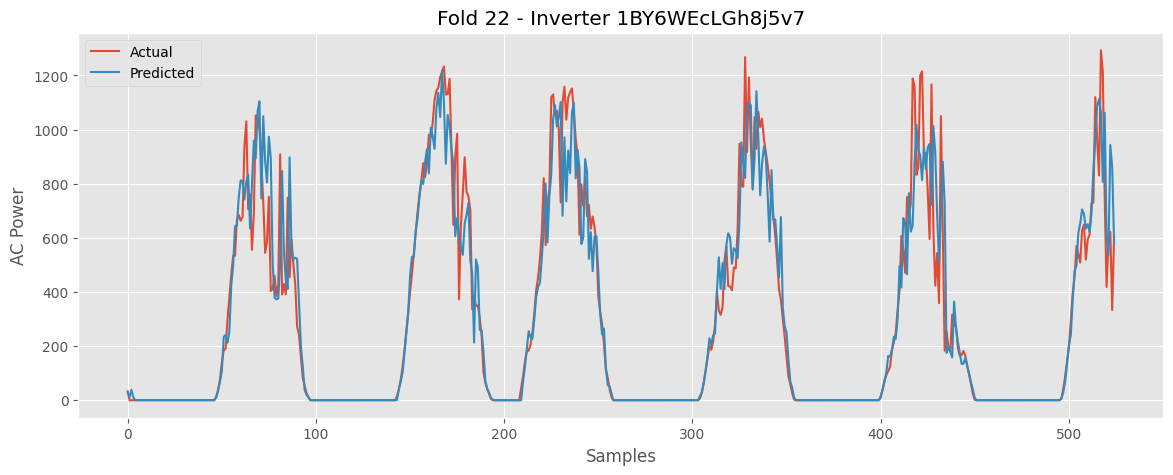


BACKTEST FOLD 23
Training Samples : 1577
Testing Samples  : 525
MAE  : 61.121
RMSE : 122.026
R²   : 0.8877
MAPE : 1329625891438984960.00%

First 10 Predictions
        Actual   Predicted
0  1032.771429  737.922804
1   924.400000  893.574607
2   578.333333  859.343661
3   281.928571  836.091357
4   284.012500  231.705518
5   451.371429  308.705411
6   270.262500  421.871000
7   261.371429  228.059339
8   182.862500  228.123000
9   159.614286  182.520286


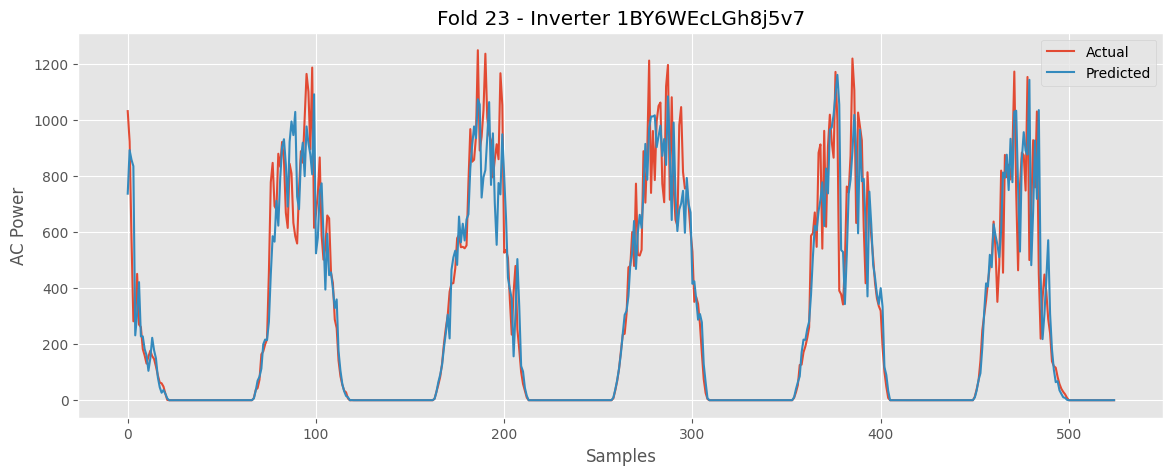


BACKTEST FOLD 24
Training Samples : 2102
Testing Samples  : 525
MAE  : 62.194
RMSE : 157.878
R²   : 0.7928
MAPE : 1329625891438984960.00%

First 10 Predictions
   Actual  Predicted
0     0.0   0.186761
1     0.0   0.186761
2     0.0   0.186761
3     0.0   0.186761
4     0.0   0.186761
5     0.0   0.186761
6     0.0   0.186761
7     0.0   0.186761
8     0.0   0.186761
9     0.0   0.186761


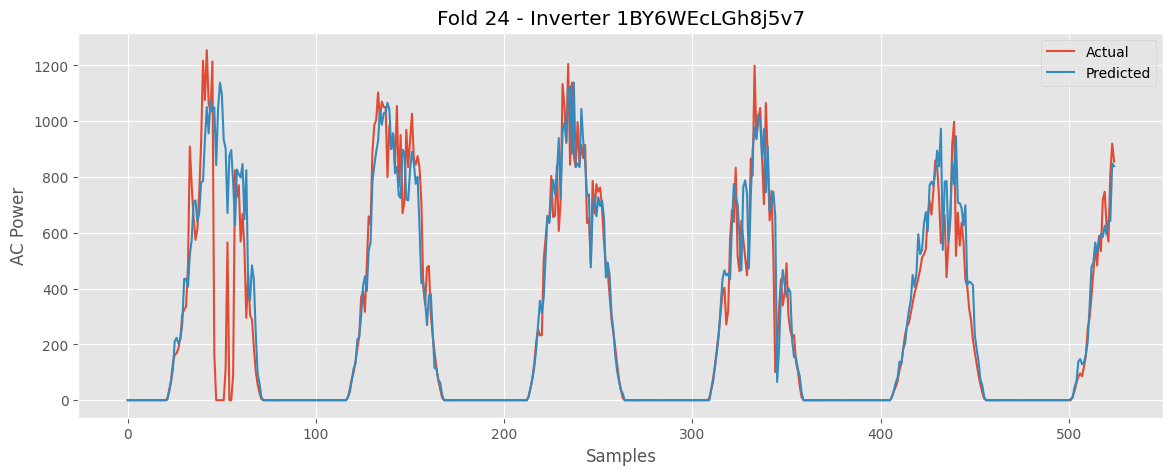


BACKTEST FOLD 25
Training Samples : 2627
Testing Samples  : 525
MAE  : 72.922
RMSE : 173.386
R²   : 0.7354
MAPE : 1329625891438984960.00%

First 10 Predictions
       Actual    Predicted
0  899.625000   929.376768
1  666.000000  1051.213393
2  645.275000   655.652232
3  711.071429   663.133786
4  728.350000   883.683518
5  730.528571   920.630411
6  762.342857   894.271857
7  853.962500   777.450714
8  801.200000   789.502327
9  691.012500   864.671661


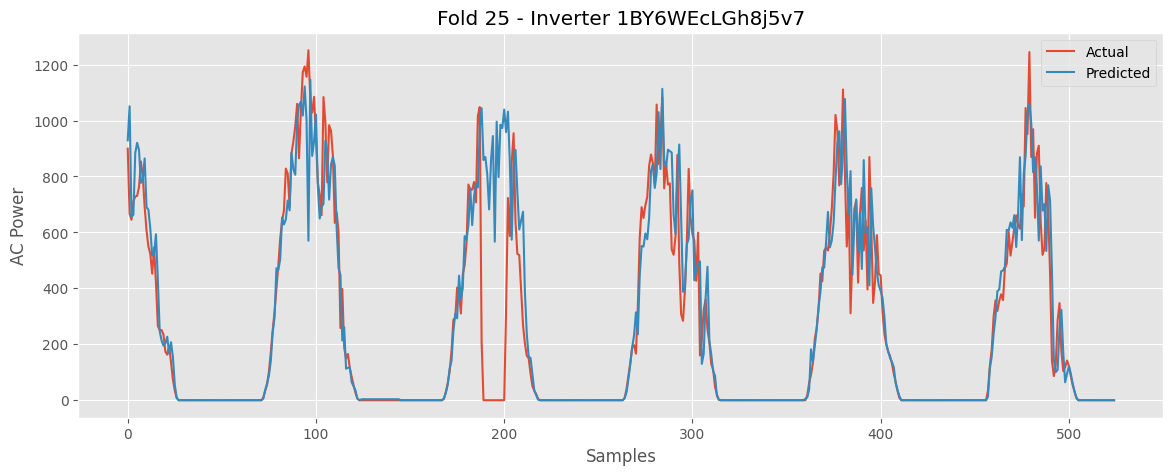

In [67]:
for train_index, test_index in tscv.split(X):

    print("\n" + "="*60)
    print(f"BACKTEST FOLD {fold}")
    print("="*60)

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    print("Training Samples :", len(X_train))
    print("Testing Samples  :", len(X_test))

    model = RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    


    mae_scores.append(mae)
    rmse_scores.append(rmse)
    r2_scores.append(r2)

    print(f"MAE  : {mae:.3f}")
    print(f"RMSE : {rmse:.3f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAPE : {mape:.2f}%")

    comparison = pd.DataFrame({
        "Actual": y_test.values,
        "Predicted": predictions
    })

    print("\nFirst 10 Predictions")
    print(comparison.head(10))

    # Plot
    plt.figure(figsize=(14,5))

    plt.plot(
        y_test.values,
        label="Actual"
    )

    plt.plot(
        predictions,
        label="Predicted"
    )

    plt.title(f"Fold {fold} - Inverter 1BY6WEcLGh8j5v7")

    plt.xlabel("Samples")
    plt.ylabel("AC Power")

    plt.grid(True)
    plt.legend()

    plt.show()

    fold += 1


In [68]:
print("\n" + "="*60)
print("FINAL BACKTEST RESULTS")
print("="*60)


print(f"Average MAE  : {np.mean(mae_scores):.3f}")
print(f"Average RMSE : {np.mean(rmse_scores):.3f}")
print(f"Average R²   : {np.mean(r2_scores):.4f}")


FINAL BACKTEST RESULTS
Average MAE  : 46.959
Average RMSE : 98.166
Average R²   : 0.9092



Feature Importance
       Feature  Importance
1     DC_POWER    0.999992
0  IRRADIATION    0.000005
2  DAILY_YIELD    0.000002


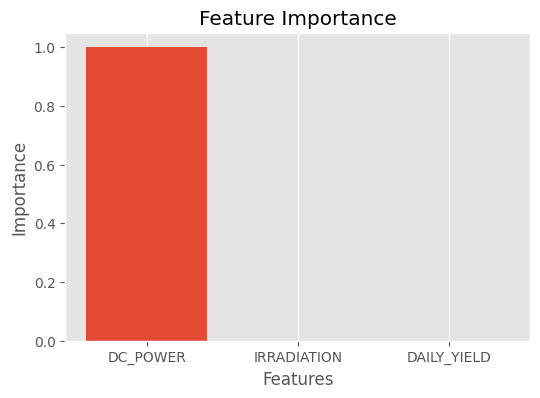

In [65]:
# =====================================================
# Feature Importance
# =====================================================

importance = pd.DataFrame({
    "Feature": features,
    "Importance": final_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance")
print(importance)

plt.figure(figsize=(6,4))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.grid(axis="y")

plt.show()

In [71]:
print(final_model.feature_names_in_)

['IRRADIATION' 'DC_POWER' 'DAILY_YIELD']
